In [1]:
%pip install numpy scipy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
    "font.size": 10,
})

## Baseframe 

In [3]:
def bs_call(S, K, T, r, sigma):
    """Price of a European call-option according to Black-Scholes."""
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))      
    d2 = d1 - sigma * np.sqrt(T)
    price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return price

In [4]:
print(bs_call(S=100, K=100, T=1, r=0.05, sigma=0.2))

10.450583572185565


In [5]:
### Put-function

def bs_put(S, K, T, r, sigma):
    """Price of a European put-option according to Black-Scholes."""
    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

print(bs_put(S=100, K=100, T=1, r=0.05, sigma=0.2))

5.573526022256971


In [6]:
### Put-call parity test
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

lhs = bs_call(S, K, T, r, sigma) - bs_put(S, K, T, r, sigma)
rhs = S - K * np.exp(-r*T)

print(lhs, rhs)
print(np.isclose(lhs, rhs))

4.877057549928594 4.877057549928594
True


## Monte-Carlo-Simulation

In [7]:
def mc_call(S, K, T, r, sigma, n_sims, seed=42):
    """Monte Carlo price of a European call."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_sims)          # n_sims random variables
    S_T = S* np.exp((r - sigma**2/2)*T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(S_T - K, 0)           # max(S_T - K, 0) for each simulation
    price = np.mean(payoff) * np.exp(-r*T)   # discounted average
    return price

print(mc_call(100, 100, 1, 0.05, 0.2, n_sims=100_000))

10.420541193153111


## Convergence plot

In [8]:
###Confidence band
def mc_call_se(S, K, T, r, sigma, n_sims, seed=42):
    """Monte Carlo price of a European call, plus its standard error."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_sims)
    S_T = S * np.exp((r - sigma**2/2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(S_T - K, 0)

    disc_payoff = payoff * np.exp(-r*T)
    price = np.mean(disc_payoff)
    se = np.std(disc_payoff, ddof=1) / np.sqrt(n_sims)
    return price, se

print(mc_call_se(100, 100, 1, 0.05, 0.2, n_sims=100_000))

(np.float64(10.420541193153113), np.float64(0.046769902520818175))


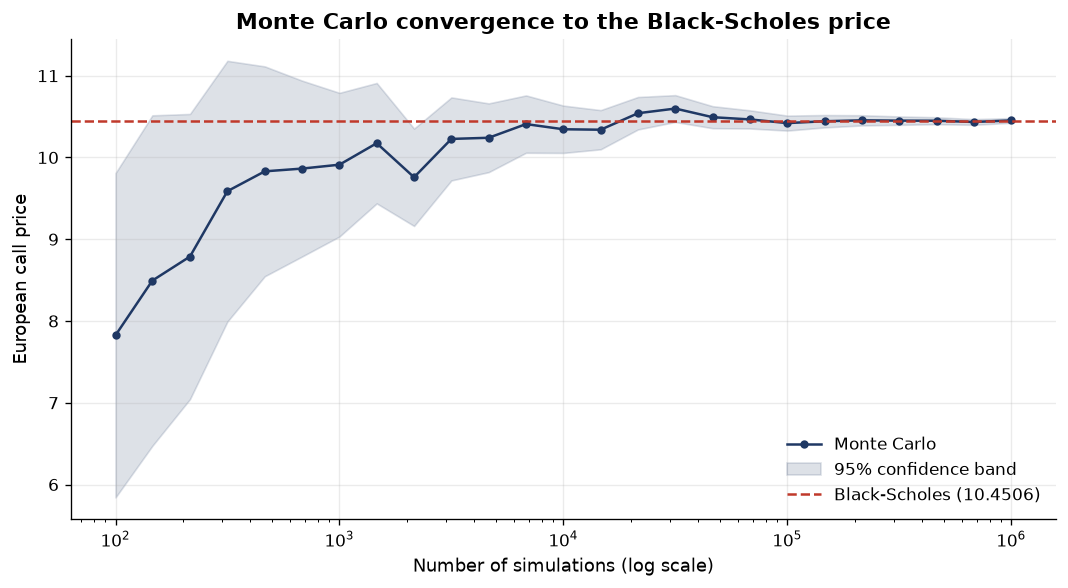

In [9]:
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

bs_price = bs_call(S, K, T, r, sigma)
n_values = np.logspace(2, 6, 25).astype(int)

results = [mc_call_se(S, K, T, r, sigma, n) for n in n_values]
mc_prices = np.array([p for p, se in results])
mc_se     = np.array([se for p, se in results])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(n_values, mc_prices, color="#1F3864", linewidth=1.5,
        marker="o", markersize=4, label="Monte Carlo")
ax.fill_between(n_values,
                mc_prices - 1.96 * mc_se,
                mc_prices + 1.96 * mc_se,
                color="#1F3864", alpha=0.15, label="95% confidence band")
ax.axhline(bs_price, color="#C0392B", linestyle="--", linewidth=1.5,
           label=f"Black-Scholes ({bs_price:.4f})")

ax.set_xscale("log")
ax.set_xlabel("Number of simulations (log scale)")
ax.set_ylabel("European call price")
ax.set_title("Monte Carlo convergence to the Black-Scholes price")
ax.legend()

fig.tight_layout()
fig.savefig("convergence_plot.png", dpi=200)
plt.show()